In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import json
import pickle
from sklearn.metrics import mean_squared_error

df = pd.read_csv('../data/df_features.csv', parse_dates=['date'])

with open('../src/models/feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

print("Shape:", df.shape)
print("Features:", len(feature_cols))
print("Date range:", df['date'].min(), "to", df['date'].max())

Shape: (382600, 38)
Features: 24
Date range: 2011-02-26 00:00:00 to 2016-05-22 00:00:00


In [2]:
# Walk-forward validation
# Train on everything before cutoff date
# Test on everything after — simulates real deployment

cutoff_date = '2015-12-31'

train = df[df['date'] <= cutoff_date].copy()
val   = df[df['date'] >  cutoff_date].copy()

print(f"Train: {train['date'].min()} to {train['date'].max()} — {len(train):,} rows")
print(f"Val:   {val['date'].min()} to {val['date'].max()} — {len(val):,} rows")
print(f"\nTrain items: {train['id'].nunique()}")
print(f"Val items:   {val['id'].nunique()}")

Train: 2011-02-26 00:00:00 to 2015-12-31 00:00:00 — 354,000 rows
Val:   2016-01-01 00:00:00 to 2016-05-22 00:00:00 — 28,600 rows

Train items: 200
Val items:   200


In [3]:
# This cell explains the key concept — read it carefully
# because interviewers WILL ask this

explanation = """
Why walk-forward validation?

Random train_test_split randomly assigns rows to train/test.
For time series this means:
- Test set contains dates from 2011, 2013, 2015 mixed together
- Model sees future data during training (data leakage)
- RMSE looks artificially good
- In production the model fails badly

Walk-forward validation:
- Train on past dates only
- Test on future dates only
- Exactly mimics real deployment
- Gives honest performance estimate

This is the professional standard for time series evaluation.
"""
print(explanation)


Why walk-forward validation?

Random train_test_split randomly assigns rows to train/test.
For time series this means:
- Test set contains dates from 2011, 2013, 2015 mixed together
- Model sees future data during training (data leakage)
- RMSE looks artificially good
- In production the model fails badly

Walk-forward validation:
- Train on past dates only
- Test on future dates only
- Exactly mimics real deployment
- Gives honest performance estimate

This is the professional standard for time series evaluation.



In [4]:
X_train = train[feature_cols]
y_train = train['sales']
X_val   = val[feature_cols]
y_val   = val['sales']

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\nBest iteration: {model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 56.777
[200]	valid_0's l2: 55.9801
[300]	valid_0's l2: 55.683
Early stopping, best iteration is:
[281]	valid_0's l2: 55.6054

Best iteration: 281


In [10]:
preds = model.predict(X_val)

# Clip negative predictions — sales can't be negative
preds = np.clip(preds, 0, None)

mse = mean_squared_error(y_val, preds)
rmse = np.sqrt(mse)

mae = np.mean(np.abs(y_val - preds))
mape = np.mean(np.abs((y_val - preds) / (y_val + 1))) * 100

print("=" * 40)
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  MAPE: {mape:.2f}%")
print("=" * 40)

  RMSE: 7.4565
  MAE:  4.7203
  MAPE: 84.25%


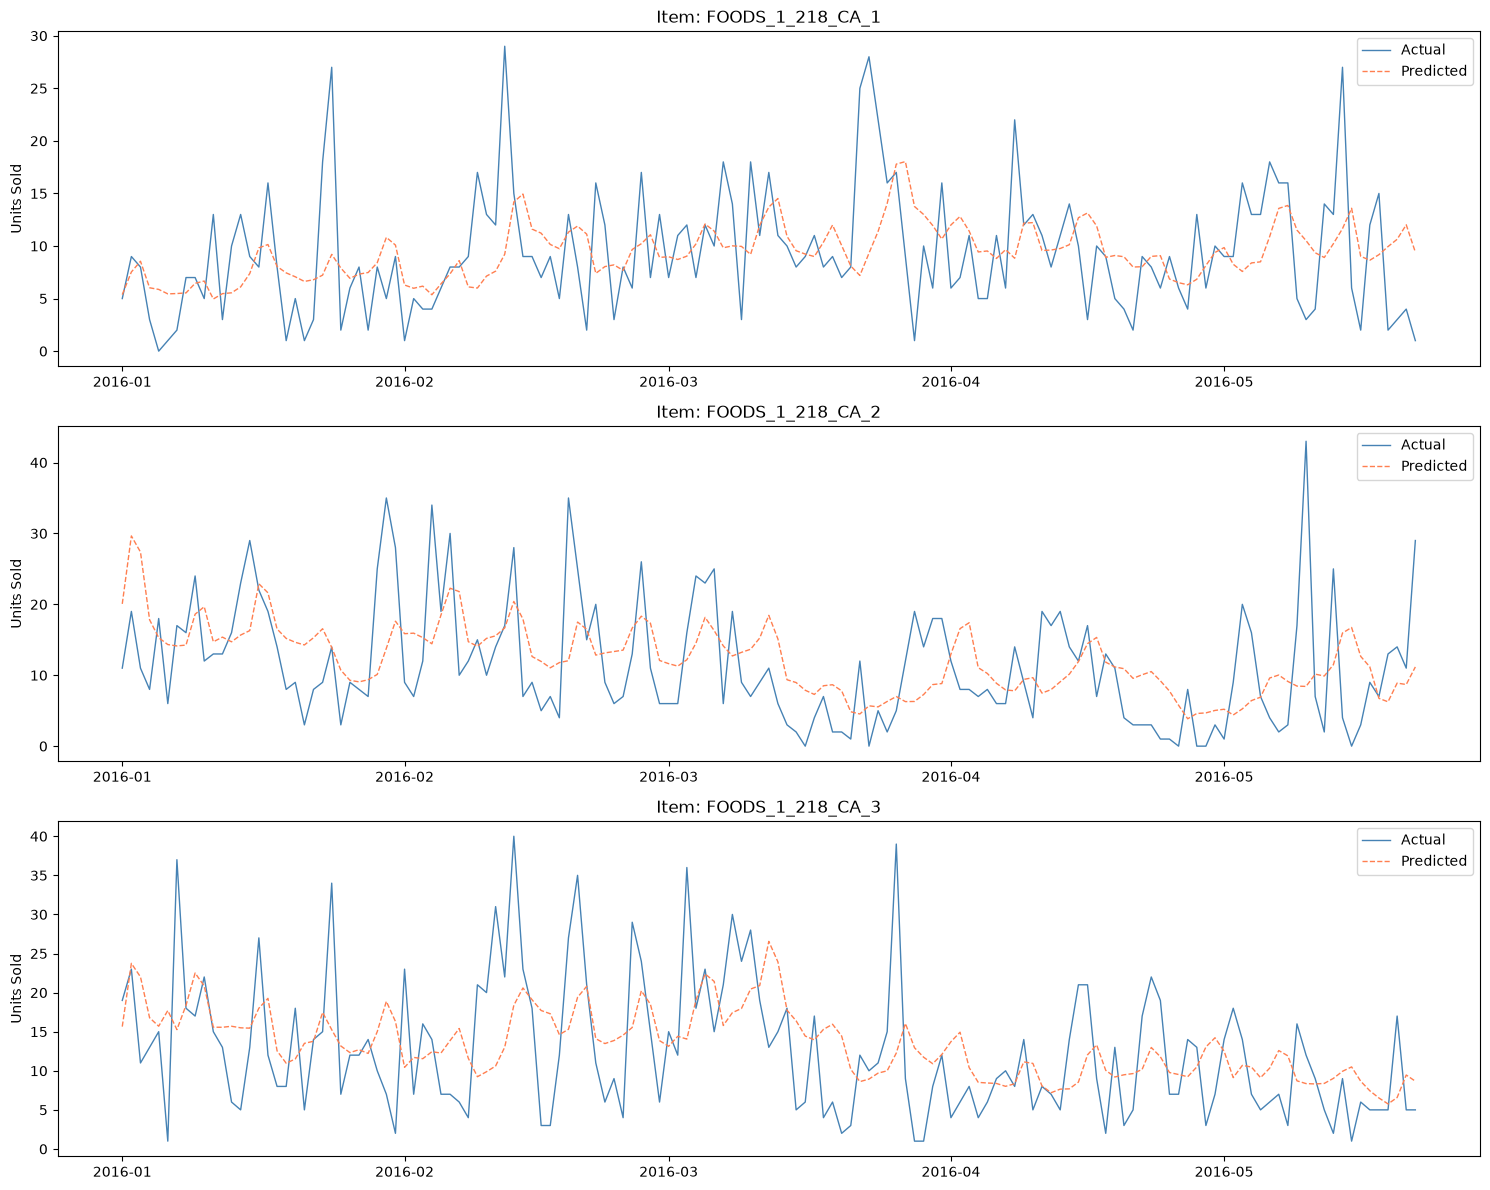

In [11]:
# Pick 3 items to visualize
sample_items = val['id'].unique()[:3]

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for i, item_id in enumerate(sample_items):
    mask = val['id'] == item_id
    actual = y_val[mask].values
    predicted = preds[mask]
    dates = val[mask]['date'].values

    axes[i].plot(dates, actual, label='Actual', color='steelblue', linewidth=1)
    axes[i].plot(dates, predicted, label='Predicted', color='coral',
                 linewidth=1, linestyle='--')
    axes[i].set_title(f"Item: {item_id.split('_evaluation')[0]}")
    axes[i].legend()
    axes[i].set_ylabel("Units Sold")

plt.tight_layout()
plt.savefig('../notebooks/lgbm_predictions.png')
plt.show()

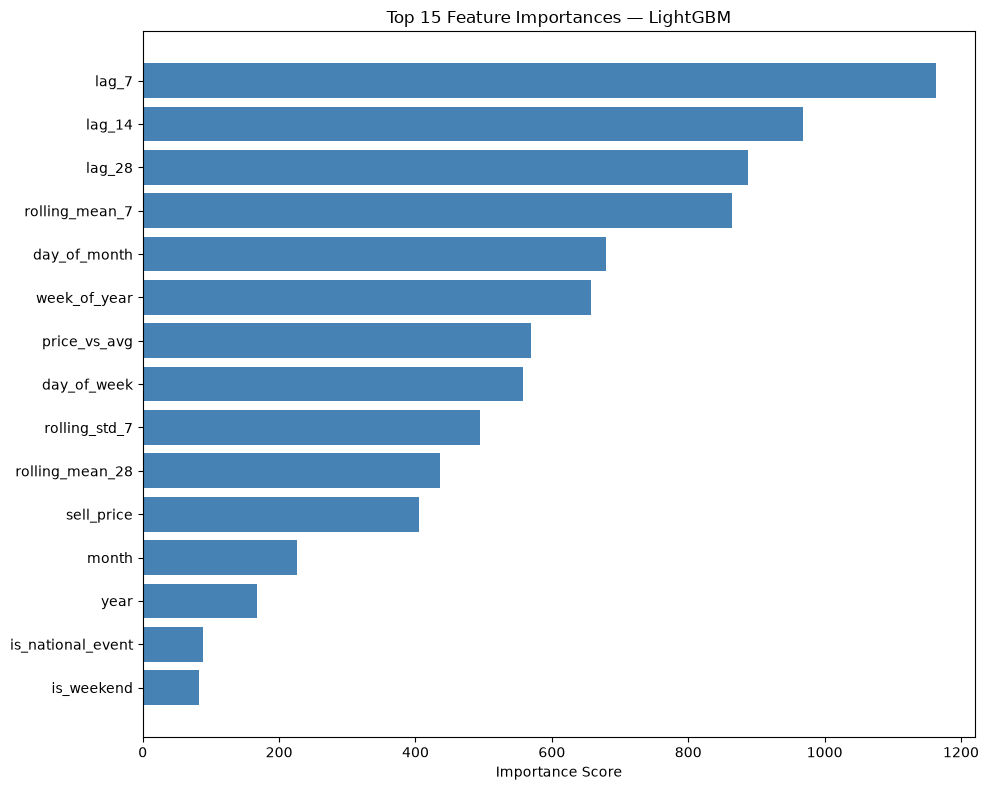


Top 10 features:
        feature  importance
          lag_7        1163
         lag_14         969
         lag_28         888
 rolling_mean_7         864
   day_of_month         680
   week_of_year         657
   price_vs_avg         570
    day_of_week         558
  rolling_std_7         495
rolling_mean_28         436


In [12]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'][:15], importance['importance'][:15], color='steelblue')
plt.title("Top 15 Feature Importances — LightGBM")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../notebooks/lgbm_feature_importance.png')
plt.show()

print("\nTop 10 features:")
print(importance.head(10).to_string(index=False))

In [13]:
# Where does the model struggle most?
val = val.copy()
val['predicted'] = preds
val['error'] = np.abs(val['sales'] - val['predicted'])
val['pct_error'] = np.abs((val['sales'] - val['predicted']) / (val['sales'] + 1)) * 100

# Error by category
print("Error by category:")
print(val.groupby('cat_id')['error'].mean().round(3))

print("\nError by day of week:")
print(val.groupby('day_of_week')['error'].mean().round(3))

print("\nError on SNAP vs non-SNAP days:")
print(val.groupby('snap_CA')['error'].mean().round(3))

Error by category:
cat_id
FOODS        4.731
HOBBIES      5.341
HOUSEHOLD    3.846
Name: error, dtype: float64

Error by day of week:
day_of_week
0    4.655
1    4.305
2    4.052
3    4.323
4    4.544
5    5.410
6    5.680
Name: error, dtype: float64

Error on SNAP vs non-SNAP days:
snap_CA
0    4.651
1    4.850
Name: error, dtype: float64


In [15]:
# Train 2 variations to find best model
# We'll log all 3 properly in MLflow tomorrow

results = []

configs = [
    {'n_estimators': 1000, 'learning_rate': 0.05, 'num_leaves': 31},   # baseline
    {'n_estimators': 1000, 'learning_rate': 0.01, 'num_leaves': 63},   # deeper
    {'n_estimators': 1000, 'learning_rate': 0.05, 'num_leaves': 15},   # simpler
]

for config in configs:
    m = lgb.LGBMRegressor(
        **config,
        random_state=42,
        verbose=-1
    )

    m.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    p = np.clip(m.predict(X_val), 0, None)

    mse = mean_squared_error(y_val, p)
    rmse = np.sqrt(mse)

    results.append({
        **config,
        'rmse': round(rmse, 4)
    })

    print(f"Config {config} → RMSE: {rmse:.4f}")

results_df = pd.DataFrame(results)

print("\nAll results:")
print(results_df.to_string(index=False))

Config {'n_estimators': 1000, 'learning_rate': 0.05, 'num_leaves': 31} → RMSE: 7.4324
Config {'n_estimators': 1000, 'learning_rate': 0.01, 'num_leaves': 63} → RMSE: 7.4279
Config {'n_estimators': 1000, 'learning_rate': 0.05, 'num_leaves': 15} → RMSE: 7.4775

All results:
 n_estimators  learning_rate  num_leaves   rmse
         1000           0.05          31 7.4324
         1000           0.01          63 7.4279
         1000           0.05          15 7.4775


In [16]:
# Find best config
best_idx = results_df['rmse'].idxmin()
best_config = configs[best_idx]
print(f"Best config: {best_config}")
print(f"Best RMSE: {results_df['rmse'].min()}")

# Retrain best model
best_model = lgb.LGBMRegressor(**best_config, random_state=42, verbose=-1)
best_model.fit(X_train, y_train,
               eval_set=[(X_val, y_val)],
               callbacks=[lgb.early_stopping(50, verbose=False)])

# Save
import os
os.makedirs('../src/models', exist_ok=True)
with open('../src/models/lgbm_best.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best model saved to src/models/lgbm_best.pkl")

Best config: {'n_estimators': 1000, 'learning_rate': 0.01, 'num_leaves': 63}
Best RMSE: 7.4279
Best model saved to src/models/lgbm_best.pkl


In [17]:
summary = f"""
Day 4 Summary — LightGBM Results
==================================
Dataset:        CA state, top 50 items
Train period:   2011-01-29 to 2015-12-31
Val period:     2016-01-01 to 2016-05-22
Features used:  {len(feature_cols)}
Validation:     Walk-forward (no data leakage)

Best config:    {best_config}
Best RMSE:      {results_df['rmse'].min()}

Top 3 features by importance:
{importance.head(3)[['feature','importance']].to_string(index=False)}
"""
print(summary)

# Save summary
with open('../src/models/lgbm_summary.txt', 'w') as f:
    f.write(summary)


Day 4 Summary — LightGBM Results
Dataset:        CA state, top 50 items
Train period:   2011-01-29 to 2015-12-31
Val period:     2016-01-01 to 2016-05-22
Features used:  24
Validation:     Walk-forward (no data leakage)

Best config:    {'n_estimators': 1000, 'learning_rate': 0.01, 'num_leaves': 63}
Best RMSE:      7.4279

Top 3 features by importance:
feature  importance
  lag_7        1163
 lag_14         969
 lag_28         888

